In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')

In [3]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41


In [4]:
#1) How much amount the companies spent on R & D ?


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  str    
 1   Company              10959 non-null  str    
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    str    
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), str(3)
memory usage: 599.4 KB


In [6]:
#converting the date column into datetime format  

In [7]:
df['Date']=pd.to_datetime(df['Date'])

In [8]:
df.info

<bound method DataFrame.info of             Date Company  R&D_Spending_USD_Mn  AI_Revenue_USD_Mn  \
0     2015-01-01  OpenAI                 5.92               0.63   
1     2015-01-02  OpenAI                 5.41               1.81   
2     2015-01-03  OpenAI                 4.50               0.61   
3     2015-01-04  OpenAI                 5.45               0.95   
4     2015-01-05  OpenAI                 3.40               1.48   
...          ...     ...                  ...                ...   
10954 2024-12-27    Meta               100.19             103.54   
10955 2024-12-28    Meta                99.12             102.37   
10956 2024-12-29    Meta                98.95             103.11   
10957 2024-12-30    Meta               100.74             103.21   
10958 2024-12-31    Meta               100.08             103.41   

       AI_Revenue_Growth_% Event  Stock_Impact_%  
0                   -36.82   NaN           -0.36  
1                    80.59   NaN            0.41 

In [9]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41


In [10]:
#show tjhe companies name

In [11]:
df['Company'].unique()

<StringArray>
['OpenAI', 'Google', 'Meta']
Length: 3, dtype: str

In [12]:
#create a new column for year only

In [13]:
df['year']=df['Date'].dt.year

In [14]:
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [15]:
#1) How much amount the companies spent on R & D ?



In [16]:
rd=df.groupby('Company')['R&D_Spending_USD_Mn'].sum()
rd

Company
Google    423341.14
Meta      264533.07
OpenAI     26482.77
Name: R&D_Spending_USD_Mn, dtype: float64

In [17]:
#bar plot

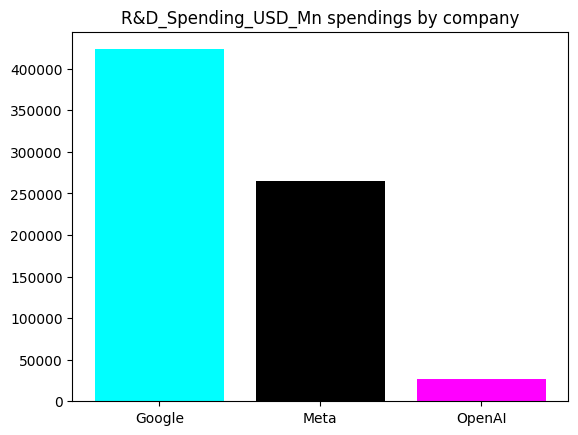

In [18]:
plt.bar(rd.index,rd.values,color=['cyan', 'black','magenta'])
plt.title('R&D_Spending_USD_Mn spendings by company')
plt.show()


In [19]:
#2) Revenue Earned by the companies


In [20]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [21]:
sum=df.groupby('Company')['AI_Revenue_USD_Mn'].sum()
sum

Company
Google    284498.38
Meta      189621.82
OpenAI      9462.89
Name: AI_Revenue_USD_Mn, dtype: float64

In [22]:
#using the bar graph

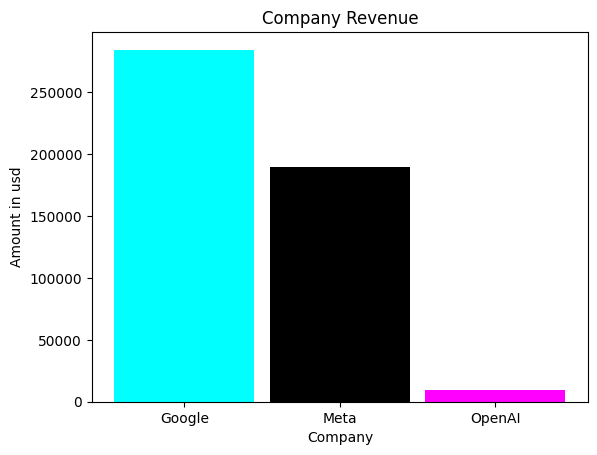

In [23]:
plt.bar(sum.index, sum.values, color=['cyan', 'black','magenta'], width=0.9)
plt.title('Company Revenue')
plt.xlabel('Company')
plt.ylabel('Amount in usd')
plt.show()

In [24]:
#using the subplots

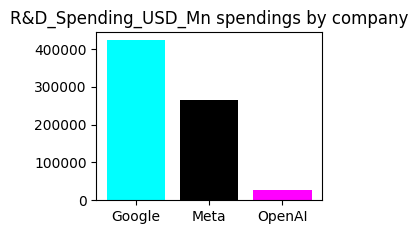

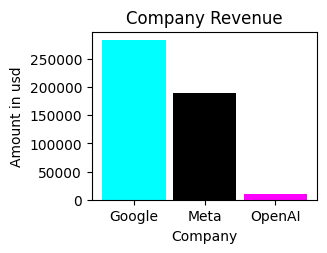

In [25]:
plt.subplot(2,2,2)
plt.bar(rd.index,rd.values,color=['cyan', 'black','magenta'])
plt.title('R&D_Spending_USD_Mn spendings by company')
plt.show()

plt.subplot(2,2,2)
plt.bar(sum.index, sum.values, color=['cyan', 'black','magenta'], width=0.9)
plt.title('Company Revenue')
plt.xlabel('Company')
plt.ylabel('Amount in usd')
plt.show()


In [26]:
#3) Date-wise Impact on the Stock


In [27]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


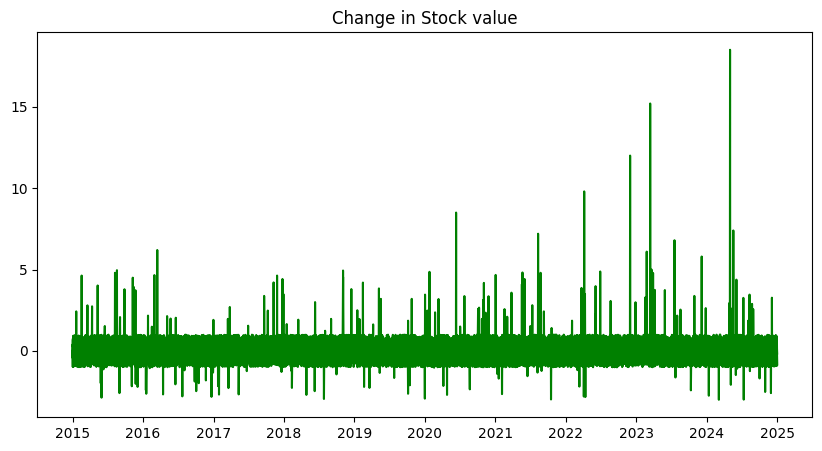

In [28]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['Stock_Impact_%'], color='green')
plt.title('Change in Stock value')
plt.show()

In [29]:
#seprate dataframe for each company

In [30]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [31]:
openai=df[df['Company']=='OpenAI']

In [32]:
google=df[df['Company']=='Google']

In [33]:
meta=df[df['Company']=='Meta']

In [34]:
meta


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
7306,2015-01-01,Meta,50.39,18.95,-5.23,NaN,-0.42,2015
7307,2015-01-02,Meta,49.80,19.77,-1.16,NaN,0.63,2015
7308,2015-01-03,Meta,49.09,19.96,-0.21,NaN,0.73,2015
7309,2015-01-04,Meta,50.66,20.48,2.38,NaN,-0.26,2015
7310,2015-01-05,Meta,51.36,19.84,-0.80,NaN,-0.37,2015
...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024


In [35]:
google

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
3653,2015-01-01,Google,79.89,30.19,0.64,NaN,-0.02,2015
3654,2015-01-02,Google,78.99,30.44,1.47,NaN,-0.98,2015
3655,2015-01-03,Google,79.20,30.46,1.53,NaN,0.78,2015
3656,2015-01-04,Google,79.59,30.55,1.82,NaN,-0.41,2015
3657,2015-01-05,Google,81.50,30.59,1.97,NaN,-0.78,2015
...,...,...,...,...,...,...,...,...
7301,2024-12-27,Google,162.16,155.36,417.88,NaN,-0.46,2024
7302,2024-12-28,Google,159.69,154.47,414.89,NaN,-0.48,2024
7303,2024-12-29,Google,161.69,154.59,415.31,NaN,0.72,2024
7304,2024-12-30,Google,158.48,155.05,416.84,NaN,-0.17,2024


In [36]:
openai

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93,2024
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25,2024
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47,2024
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69,2024


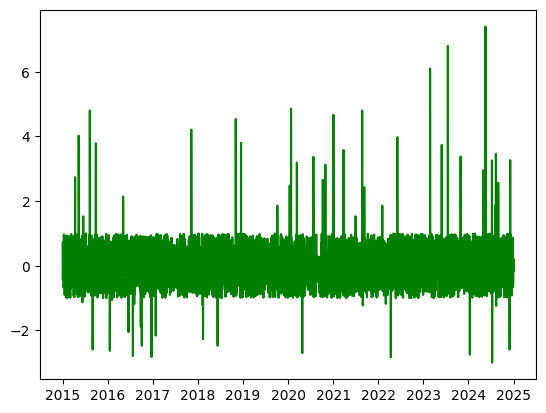

In [37]:
plt.plot(meta['Date'],meta['Stock_Impact_%'], color='green')
plt.show()

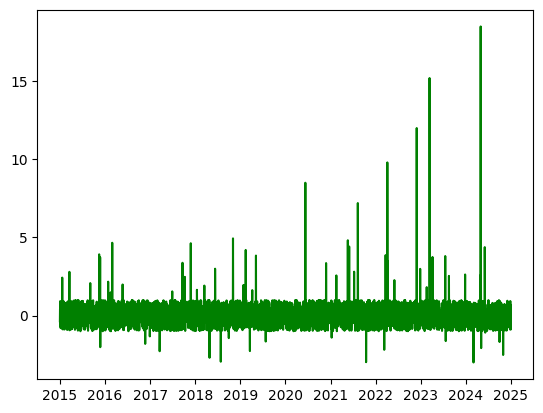

In [38]:
plt.plot(openai['Date'],openai['Stock_Impact_%'], color='green')
plt.show()


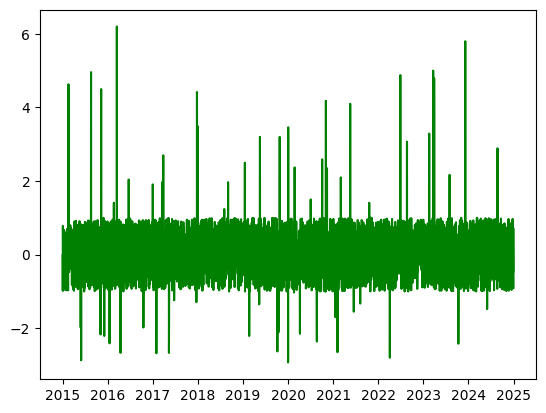

In [39]:
plt.plot(google['Date'],google['Stock_Impact_%'], color='green')
plt.show()


In [40]:
#4) Events when Maximum Stock Impact was observed



In [41]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [42]:
openai

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93,2024
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25,2024
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47,2024
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69,2024


In [43]:
openai.sort_values(by='Stock_Impact_%' , ascending=False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
3408,2024-05-01,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.50,2024
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.20,2023
2890,2022-11-30,OpenAI,10.60,3.18,217.72,ChatGPT (GPT-3.5) launch,12.00,2022
2652,2022-04-06,OpenAI,9.24,3.48,247.93,DALL·E 2 release,9.80,2022
1988,2020-06-11,OpenAI,5.90,2.62,161.56,GPT-3 release,8.50,2020
...,...,...,...,...,...,...,...,...
3590,2024-10-30,OpenAI,11.05,5.27,427.50,AI-powered search update,-2.52,2024
1212,2018-04-27,OpenAI,5.38,1.76,76.47,AI ethics policy update,-2.70,2018
1303,2018-07-27,OpenAI,7.44,0.97,-2.63,AI-powered search update,-2.95,2018
2480,2021-10-16,OpenAI,8.39,2.78,178.28,AI Ads Optimization upgrade,-2.98,2021


In [44]:
meta


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
7306,2015-01-01,Meta,50.39,18.95,-5.23,NaN,-0.42,2015
7307,2015-01-02,Meta,49.80,19.77,-1.16,NaN,0.63,2015
7308,2015-01-03,Meta,49.09,19.96,-0.21,NaN,0.73,2015
7309,2015-01-04,Meta,50.66,20.48,2.38,NaN,-0.26,2015
7310,2015-01-05,Meta,51.36,19.84,-0.80,NaN,-0.37,2015
...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024


In [45]:
meta.sort_values(by='Stock_Impact_%' , ascending=False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
10731,2024-05-18,Meta,103.64,103.05,415.23,LLaMA 3 release (predicted),7.40,2024
10426,2023-07-18,Meta,92.44,85.67,328.37,LLaMA 2 release,6.80,2023
10282,2023-02-24,Meta,93.71,86.98,334.89,LLaMA 1 release,6.10,2023
9156,2020-01-25,Meta,72.73,49.10,145.49,Cloud AI launch,4.86,2020
9732,2021-08-23,Meta,78.19,59.36,196.79,Cloud AI launch,4.80,2021
...,...,...,...,...,...,...,...,...
10604,2024-01-12,Meta,99.37,104.28,421.42,AI Video Recommendation upgrade,-2.75,2024
7875,2016-07-23,Meta,53.76,23.97,19.83,AI-powered search update,-2.79,2016
8026,2016-12-21,Meta,53.18,23.42,17.11,AI-powered search update,-2.82,2016
9964,2022-04-12,Meta,84.90,71.99,259.95,AI ethics policy update,-2.83,2022


In [46]:
google.sort_values(by='Stock_Impact_%' , ascending=False) 

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
4092,2016-03-15,Google,84.56,36.22,20.73,AlphaGo beats Lee Sedol,6.20,2016
6914,2023-12-06,Google,146.59,129.17,330.55,Gemini AI release,5.80,2023
6654,2023-03-21,Google,149.34,129.76,332.53,Bard chatbot launch,5.00,2023
3883,2015-08-19,Google,79.27,30.89,2.98,AI partnership deal,4.96,2015
6388,2022-06-28,Google,137.71,107.96,259.85,AI ethics policy update,4.88,2022
...,...,...,...,...,...,...,...,...
4122,2016-04-14,Google,87.19,36.08,20.28,AI partnership deal,-2.67,2016
4412,2017-01-29,Google,92.21,43.25,44.17,AI Ads Optimization upgrade,-2.68,2017
6303,2022-04-04,Google,138.00,106.81,256.04,AI Video Recommendation upgrade,-2.80,2022
3803,2015-05-31,Google,81.14,29.30,-2.32,Cloud AI launch,-2.87,2015


In [47]:
#5) AI Revenue Growth of the companies


In [48]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [49]:
df.groupby('Company')['AI_Revenue_Growth_%'].mean()

Company
Google    159.602313
Meta      159.542223
OpenAI    159.043427
Name: AI_Revenue_Growth_%, dtype: float64

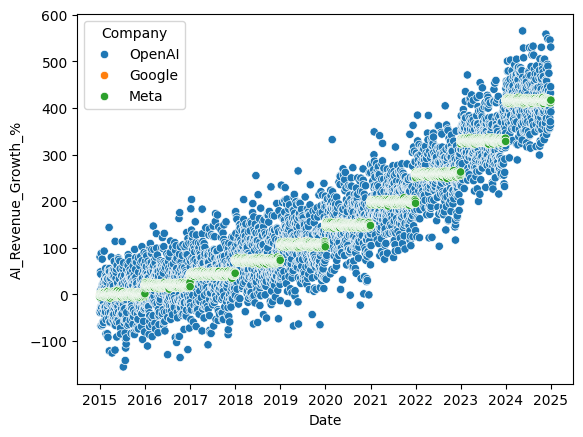

In [50]:
sns.scatterplot(x='Date', y='AI_Revenue_Growth_%' , data=df ,hue='Company')
plt.show()

In [51]:
df.sort_values(by='AI_Revenue_Growth_%')

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
189,2015-07-09,OpenAI,5.66,-0.55,-155.43,NaN,0.70,2015
205,2015-07-25,OpenAI,5.23,-0.42,-141.61,NaN,-0.62,2015
649,2016-10-11,OpenAI,5.37,-0.35,-135.31,NaN,0.12,2016
548,2016-07-02,OpenAI,5.19,-0.29,-129.11,NaN,-0.31,2016
98,2015-04-09,OpenAI,4.80,-0.25,-125.50,NaN,-0.56,2015
...,...,...,...,...,...,...,...,...
3508,2024-08-09,OpenAI,9.92,6.33,532.86,NaN,0.77,2024
3645,2024-12-24,OpenAI,8.79,6.46,546.07,NaN,0.45,2024
3627,2024-12-06,OpenAI,8.51,6.49,548.83,NaN,-0.15,2024
3612,2024-11-21,OpenAI,10.16,6.59,558.70,NaN,0.63,2024


In [52]:
#OpenAi revenue growth year by year

In [54]:
openai

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93,2024
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25,2024
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47,2024
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69,2024


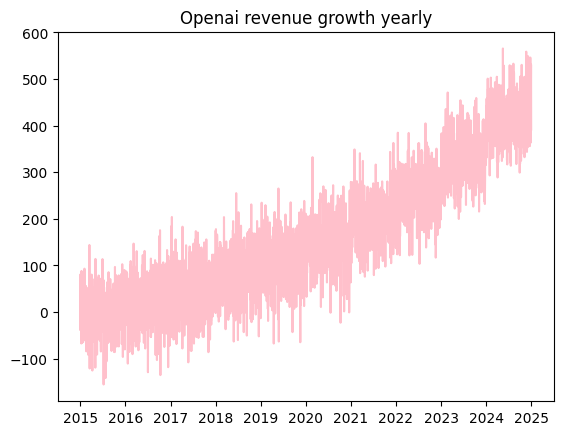

In [63]:
plt.plot(openai['Date'], openai['AI_Revenue_Growth_%'] , color='pink')
plt.title('Openai revenue growth yearly')
plt.show()

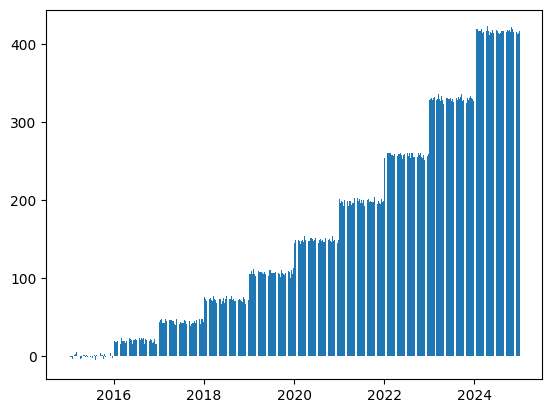

In [66]:
 plt.bar(meta['Date'],meta['AI_Revenue_Growth_%'])
plt.title('meta revenue growth yearly')
 plt.show()

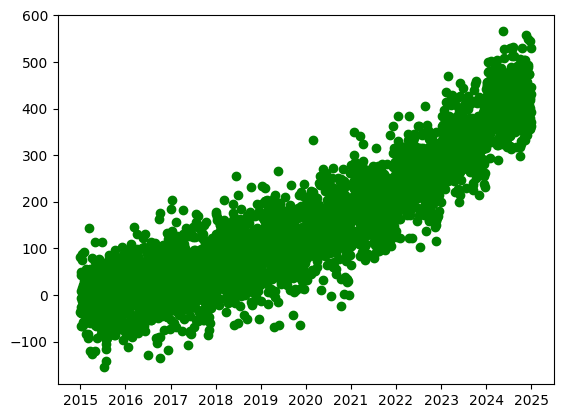

In [72]:
plt.scatter(openai['Date'], openai['AI_Revenue_Growth_%'], color='green' )
plt.show()

In [73]:
#6) Correlation between the columns


In [74]:
df.corr(numeric_only=True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,year
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.297701
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.526478
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.952199
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.016525
year,0.297701,0.526478,0.952199,0.016525,1.000000


<Axes: >

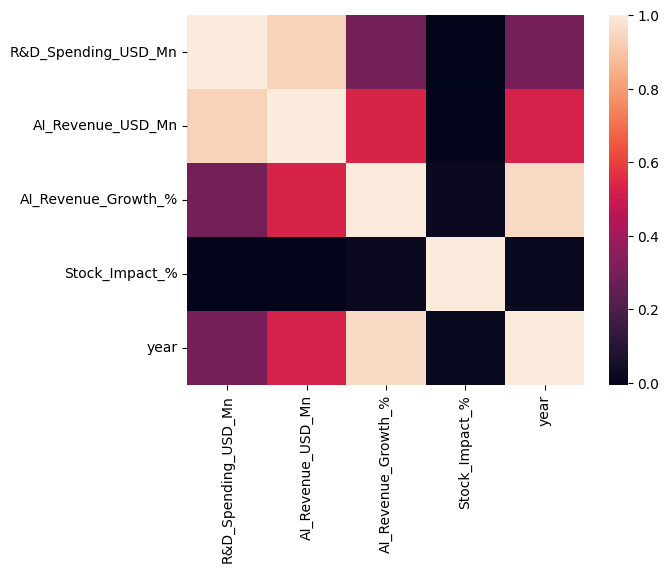

In [76]:
sns.heatmap(df.corr(numeric_only=True))

In [77]:
#7) Expenditure vs Revenue year-by-year


In [78]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [90]:
s=df.groupby('year')['R&D_Spending_USD_Mn'].sum()

In [91]:
s

year
2015    49304.23
2016    53349.94
2017    57475.12
2018    62002.16
2019    67071.51
2020    72602.53
2021    78207.32
2022    84390.17
2023    91193.92
2024    98760.08
Name: R&D_Spending_USD_Mn, dtype: float64

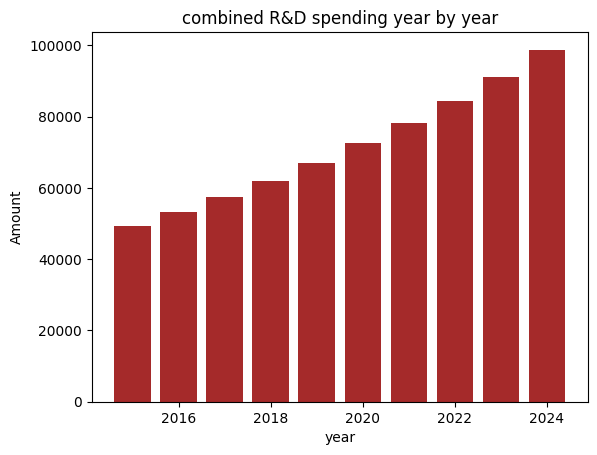

In [102]:
plt.bar(s.index, s.values , color='brown')
plt.title("combined R&D spending year by year")
plt.xlabel('year')
plt.ylabel('Amount')
plt.show()

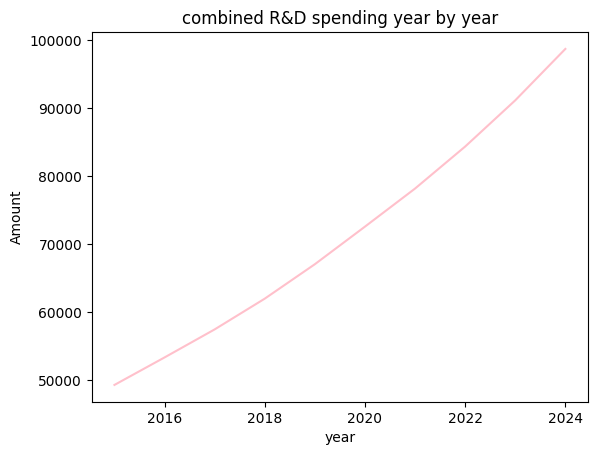

In [101]:
plt.plot(s.index, s.values, color='pink')
plt.title("combined R&D spending year by year")
plt.xlabel('year')
plt.ylabel('Amount')
plt.show()

In [106]:
#Revenue year-by-year

In [107]:

df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [108]:
r=df.groupby('year')['AI_Revenue_Growth_%'].sum()

In [105]:
r

year
2015      -786.75
2016     21571.45
2017     47427.79
2018     80966.81
2019    116899.61
2020    163669.05
2021    217664.90
2022    281449.96
2023    361101.15
2024    456856.66
Name: AI_Revenue_Growth_%, dtype: float64

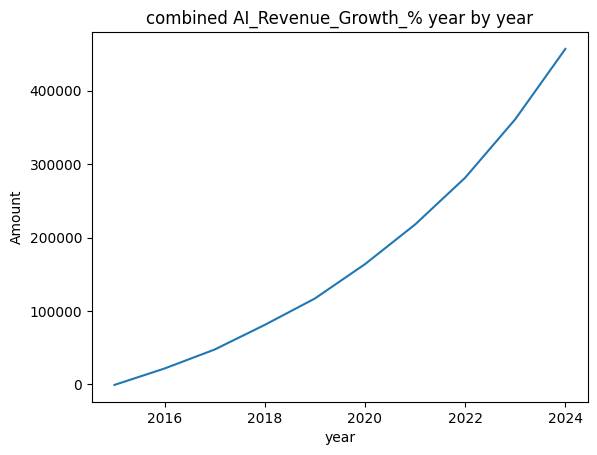

In [113]:
plt.plot(r.index, r.values)
plt.title("combined AI_Revenue_Growth_% year by year")
plt.xlabel('year')
plt.ylabel('Amount')
plt.show()


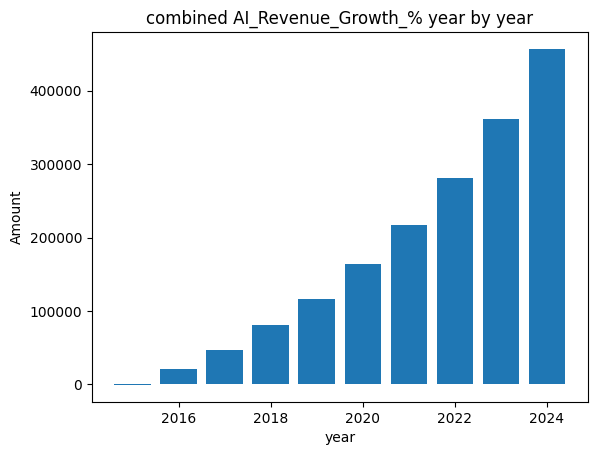

In [112]:
plt.bar(r.index, r.values)
plt.title("combined AI_Revenue_Growth_% year by year")
plt.xlabel('year')
plt.ylabel('Amount')
plt.show()


In [114]:
#Expenditure vs Revenue year-by-year


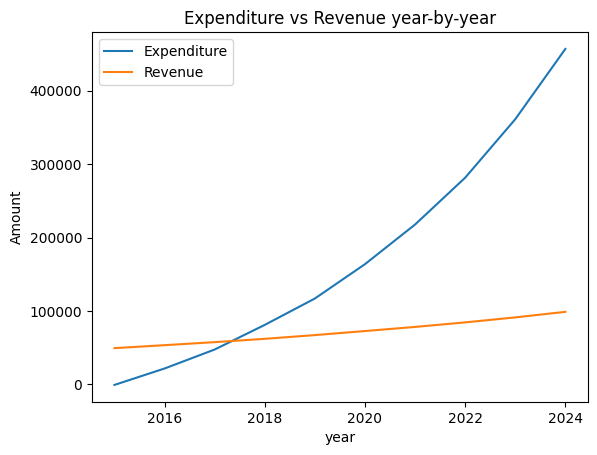

In [126]:
plt.plot(r.index, r.values)
plt.title("Expenditure vs Revenue year-by-year")
plt.xlabel('year')
plt.ylabel('Amount')
plt.plot(s.index, s.values)
plt.legend(['Expenditure','Revenue'])
plt.show()


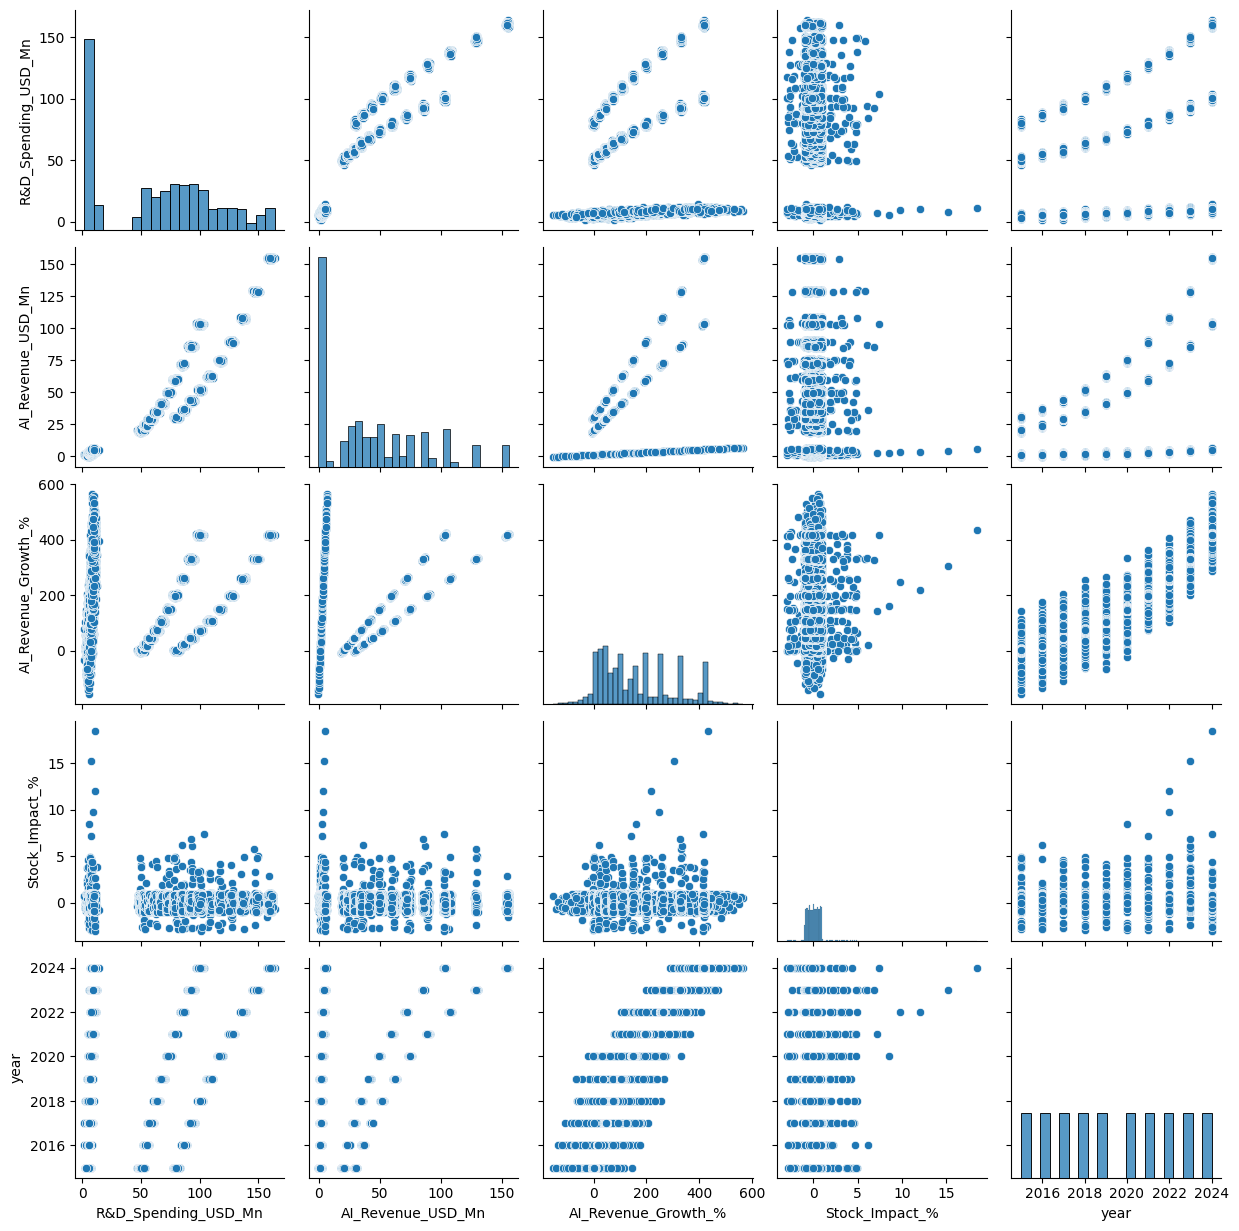

In [137]:
sns.pairplot(df)

In [138]:
#8) Change in the index wrt Year & Company


In [139]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [149]:
ss=df.groupby(['year','Company'])['Stock_Impact_%'].sum()
ss

year  Company
2015  Google    -11.02
      Meta        8.91
      OpenAI     14.89
2016  Google     20.31
      Meta      -15.70
      OpenAI     18.70
2017  Google      9.78
      Meta       -5.39
      OpenAI     -3.91
2018  Google     25.11
      Meta       13.34
      OpenAI      6.24
2019  Google      0.17
      Meta       -2.68
      OpenAI      7.45
2020  Google     -0.11
      Meta        0.88
      OpenAI      4.04
2021  Google      3.79
      Meta       -7.09
      OpenAI     19.03
2022  Google     23.24
      Meta       11.45
      OpenAI     38.67
2023  Google     16.54
      Meta       12.83
      OpenAI     30.26
2024  Google      7.93
      Meta       19.11
      OpenAI     13.34
Name: Stock_Impact_%, dtype: float64

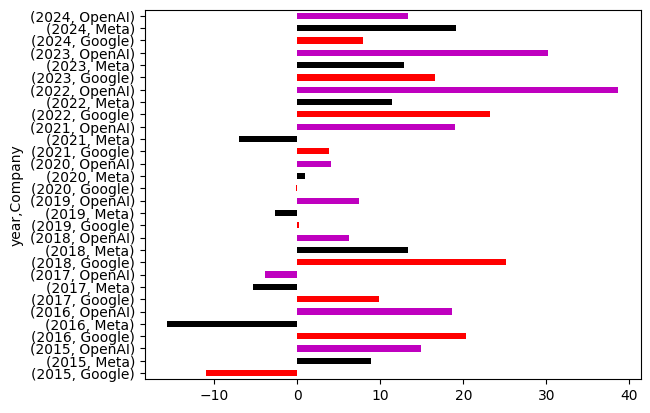

In [151]:
ss.plot(kind='barh' , color=['r','black','m'])
plt.show()